# COM2028 Coursework 24/25 Summary

## Question 1 - Model Training and Tuning (40 Marks)

### Question 1.1 (10 Marks)
- **Task:** Improve the validation AUC result by modifying hyperparameters (`num_epochs`, `learning_rate`, and `weight_decay_rate`) to achieve `val_AUC > 0.8`.

### Question 1.2 (10 Marks)
- **Task:** Enhance model performance using data augmentation. Add the following augmentations to the training images:
  1. Random rotations of 10°.
  2. Random horizontal flips with a 50% probability.

### Question 1.3 (10 Marks)
- **Task:** Compare the validation AUC results of two optimisers (Adam and SGD). Automatically select the best-performing optimiser based on the validation AUC results  and run a final training with it.

### Question 1.4 (10 Marks)
- **Task:** Build a new CNN model called `Net2` with the following architecture:
  - **Layer 1**: Input convolutional layer with 32 filters (5x5), followed by ReLU activation and max pooling (kernel size = 3, stride = 3).
  - **Layer fc**: Linear layer with 300 nodes, ReLU activation, and another linear layer with `num_classes` nodes.

---

## Question 2 - Classification Metrics (10 Marks)

### Task:
- **Objective:** Write a function `compute_classification_metrics(all_outputs, all_targets)` to calculate:
  - AUPR (Area Under the Precision-Recall Curve).
  - Precision, Recall, and F1 Score for classifications with probability > 0.5.
  - Use `precision_score`, `recall_score`, `f1_score`, `precision_recall_curve`, and `auc` from `sklearn.metrics`.

---

## Question 3 - ROC Curve (10 Marks)

### Task:
- **Objective:** Plot the ROC curve for binary classification. You are given a function to plot the ROC curve but it lacks the necessary definition of which class’s probability to select. Fix the code by selecting the correct probability from the `all_outputs` array.

---

## Question 4 - Confusion Matrix (10 Marks)

### Task:
- **Objective:** Write a function `compute_confusion_matrix(all_outputs, all_targets)` that calculates the confusion matrix for the binary classification problem using the predicted outputs (`all_outputs`) and ground truth labels (`all_targets`).

---

## Question 5 - Cross Validation (10 Marks)

### Question 5.1 (10 Marks)
- **Task:** Fix the incorrect implementation of the cross-validation function `cross_validate_model_with_serious_mistake(combined_dataset, kf, learning_rate, weight_decay_rate, num_epochs)`. Correct it to a functional version: `cross_validate_model(combined_dataset, kf, learning_rate, weight_decay_rate, num_epochs)`.

---

## Question 6 - Fine-Tuning Pre-Trained Model (20 Marks)

### Task:
- **Objective:** Fine-tune a pre-trained ResNet18 model. Make necessary changes to adapt the model for your own classification task.

---

## Question 6.1 - Preprocessing for ResNet18 (10 Marks)

### Task:
- **Objective:** Modify the `train_transform` and `val_test_transform` to:
  1. Resize the images to 224x224 pixels (use `transforms.Resize(224)`).
  2. Convert grayscale images to 3 RGB channels (use `transforms.Lambda(lambda x: x.repeat(3, 1, 1))`).
  3. Normalize the images using the ImageNet normalization statistics (use `transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`).

---

## Question 6.2 - Modify ResNet18 Architecture (10 Marks)

### Task:
- **Objective:** Load the pre-trained ResNet18 model from torchvision and modify the final fully connected layer to have `n_classes` output nodes.
  - Ensure the model is initialized with weights from ImageNet (`weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1`).


## Important Notes:

1. **Follow the instructions carefully:** For each question, you will need to modify only the sections of the code that are specified.  In particular, you'll see:

**# YOUR CODE HERE**

**raise NotImplementedError()**

Please replace **raise NotImplementedError()** with your code. **Do not change anything else in the notebook unless directed to do so**.

4. **Testing and validation:** Each change you make will be automatically tested using a set of unit tests that are hidden from this notebook.

5. **Keep the code clean:** For each question, only modify the code within the cells indicated by the question. Do not add extra cells or change the structure of the notebook unless explicitly instructed.

6. **Error handling:** If you encounter any issues or errors, ensure you carefully debug your code. If you are unable to resolve the issue, ask for help, but remember that the solution must follow the given instructions.

7. **Final Submission:** Once you have completed all the questions, submit the notebook as instructed. Make sure to run all the cells to ensure that your changes work correctly. If the notebook crashes at any point, none of the cells will be marked.



In [2]:
# installing MedMNIST dataset
!pip install medmnist

# load main libraries
from tqdm import tqdm
from tqdm import trange
import os
import random
from collections import OrderedDict
from copy import deepcopy


import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.utils.data as data
from torchvision import transforms
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, precision_recall_curve, auc, roc_auc_score,
                             accuracy_score, roc_curve as sk_roc_curve)
from sklearn.model_selection import KFold
import seaborn as sns

import medmnist
from medmnist import INFO, Evaluator
import matplotlib.pyplot as plt

import medmnist
from medmnist import INFO, Evaluator
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.8 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=

In [3]:
#CPU or GPU?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set the dataset to BreastMNIST
data_flag = 'breastmnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

Using device: cpu


In [4]:
# Image pre-processing
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Datasets and DataLoaders
train_dataset = getattr(medmnist, INFO[data_flag]['python_class'])(split='train', transform=train_transform, download=True)
val_dataset = getattr(medmnist, INFO[data_flag]['python_class'])(split='val', transform=val_test_transform, download=True)
test_dataset = getattr(medmnist, INFO[data_flag]['python_class'])(split='test', transform=val_test_transform, download=True)

batch_size = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
train_loader_at_eval = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

train_evaluator = Evaluator(data_flag, 'train')
val_evaluator = Evaluator(data_flag, 'val')
test_evaluator = Evaluator(data_flag, 'test')

100%|██████████| 560k/560k [00:00<00:00, 934kB/s] 


Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 546
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0
Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 156
    Root location: /root/.medmnist
    Split: test
    Task: binary-class
    Number of channels: 1
    Meaning of labels: 

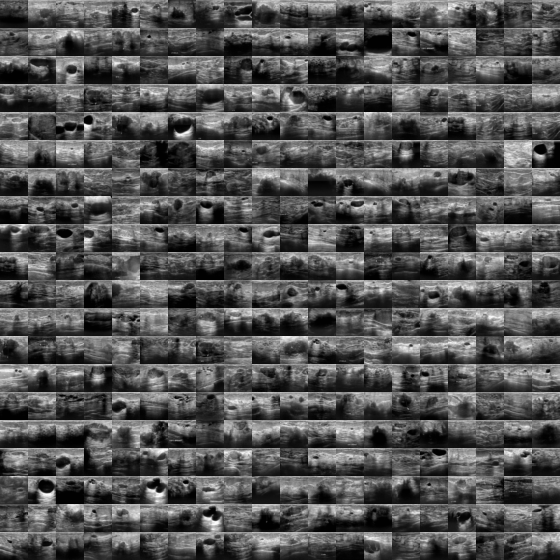

In [5]:
print(train_dataset)
print("===================")
print(test_dataset)
# montage
print("Visualisation of training data")
train_dataset.montage(length=20)

In [6]:
# define a CNN model
class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [7]:
# Hyperparameters
learning_rate = 1.0
weight_decay_rate = 0.0
num_epochs = 1
criterion = nn.CrossEntropyLoss()

In [8]:
# Log for storing loss, AUC and accuracy for all three splits
logs = ['loss', 'auc', 'acc']
train_logs = ['train_'+log for log in logs]
val_logs = ['val_'+log for log in logs]
test_logs = ['test_'+log for log in logs]
log_dict = OrderedDict.fromkeys(train_logs+val_logs+test_logs, 0)

In [9]:
def train_model(model, train_loader, criterion, optimiser, device):
    total_loss = []

    model.train()
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        optimiser.zero_grad()

        # Moving to GPU for faster computation
        outputs = model(inputs.to(device))

        targets = torch.squeeze(targets, 1).long().to(device) # Fit size
        loss = criterion(outputs, targets)

        total_loss.append(loss.item())

        loss.backward()
        optimiser.step()

    epoch_loss = sum(total_loss)/len(total_loss)
    return epoch_loss

In [10]:
def test_model(model, evaluator, data_loader, criterion, device):
    model.eval()

    total_loss = []
    y_score = torch.tensor([]).to(device)
    all_outputs = torch.tensor([]).to(device)  # Prediction logits
    all_targets = torch.tensor([]).to(device)  # True labels

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(data_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)

            # Storing logits and true labels for use in later computation
            all_outputs = torch.cat((all_outputs, outputs), 0)
            all_targets = torch.cat((all_targets, targets), 0)

            targets = torch.squeeze(targets, 1).long() # Fix size
            loss = criterion(outputs, targets)

            total_loss.append(loss.item())

            # Softmax to get probabilities from logits
            m = nn.Softmax(dim=1)
            prob_outputs = m(outputs).to(device)
            y_score = torch.cat((y_score, prob_outputs), 0)  # Store probabilities separately

    # Using medmnist evaluator to compute auc and acc from probabilities
    y_score = y_score.detach().cpu().numpy()
    auc, acc = evaluator.evaluate(y_score)

    test_loss = sum(total_loss) / len(total_loss)

    # First three will go into the log
    return [test_loss, auc, acc, all_outputs.cpu(), all_targets.cpu()]

In [11]:
def train_val_test_procedure(model, num_epochs, criterion, optimiser, device, train_loader,
                             train_evaluator, train_loader_at_eval, val_evaluator, val_loader,
                             test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs):

    best_auc = 0
    best_epoch = 0
    best_model = deepcopy(model)

    train_loss_values = []
    val_loss_values = []

    for epoch in trange(num_epochs):
        # Train model for this epoch
        train_loss = train_model(model, train_loader, criterion, optimiser, device)

        train_results = test_model(model, train_evaluator, train_loader_at_eval, criterion, device)
        train_metrics = train_results[:3]  # Slices loss, auc, acc to be used in the log
        train_outputs, train_targets = train_results[3:]  # Stores all_outputs and all_targets to be used for computation

        val_results = test_model(model, val_evaluator, val_loader, criterion, device)
        val_metrics = val_results[:3]
        val_outputs, val_targets = val_results[3:]

        test_results = test_model(model, test_evaluator, test_loader, criterion, device)
        test_metrics = test_results[:3]
        test_outputs, test_targets = test_results[3:]

        # Store loss, auc, acc in respective logs
        for i, key in enumerate(train_logs):
            log_dict[key] = train_metrics[i]
        for i, key in enumerate(val_logs):
            log_dict[key] = val_metrics[i]
        for i, key in enumerate(test_logs):
            log_dict[key] = test_metrics[i]

        train_loss_values.append(train_metrics[0])
        val_loss_values.append(val_metrics[0])

        cur_auc = val_metrics[1]

        # Update best model if Val-AUC is new highest
        if cur_auc > best_auc:
            best_epoch = epoch
            best_auc = cur_auc
            best_model = deepcopy(model) # So that model can be stored
            best_outputs = deepcopy(test_outputs)  # Store best outputs for test set with best val auc
            best_targets = deepcopy(test_targets)  # Store best targets for test set with best val auc
            print(f'New best validation AUC: {best_auc} at Epoch: {best_epoch}')


    # Set up the plot
    epochs = range(1, len(train_loss_values) + 1)
    # Plot the losses
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, train_loss_values, label='Training Loss', marker='o')
    plt.plot(epochs, val_loss_values, label='Validation Loss', marker='s')
    # Add labels, title, and legend
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_epoch, best_auc, best_model, best_outputs, best_targets

In [12]:
def full_training(model, num_epochs, criterion, optimiser, device, train_loader,train_evaluator, train_loader_at_eval,
                  val_evaluator, val_loader, test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs):

    best_epoch, best_auc, best_model, best_outputs, best_targets= train_val_test_procedure(model, num_epochs, criterion, optimiser, device, train_loader,
                                                                                       train_evaluator, train_loader_at_eval, val_evaluator, val_loader,
                                                                                       test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs)

    train_metrics = test_model(best_model, train_evaluator, train_loader_at_eval, criterion, device)
    val_metrics = test_model(best_model, val_evaluator, val_loader, criterion, device)
    test_metrics = test_model(best_model, test_evaluator, test_loader, criterion, device)

    # Retrieve and print AUC and accuracy for the three splits from the log
    train_log = 'Train   AUC: %.5f  Accuracy: %.5f\n' % (train_metrics[1], train_metrics[2])
    val_log = 'Validation   AUC: %.5f  Accuracy: %.5f\n' % (val_metrics[1], val_metrics[2])
    test_log = 'Test   AUC: %.5f  Accuracy: %.5f\n' % (test_metrics[1], test_metrics[2])

    log = '%s\n' % (data_flag) + train_log + val_log + test_log
    print(log)

    return test_metrics[1], test_metrics[2], best_auc, best_model, best_outputs, best_targets


100%|██████████| 1/1 [00:03<00:00,  3.25s/it]

New best validation AUC: 0.5 at Epoch: 0


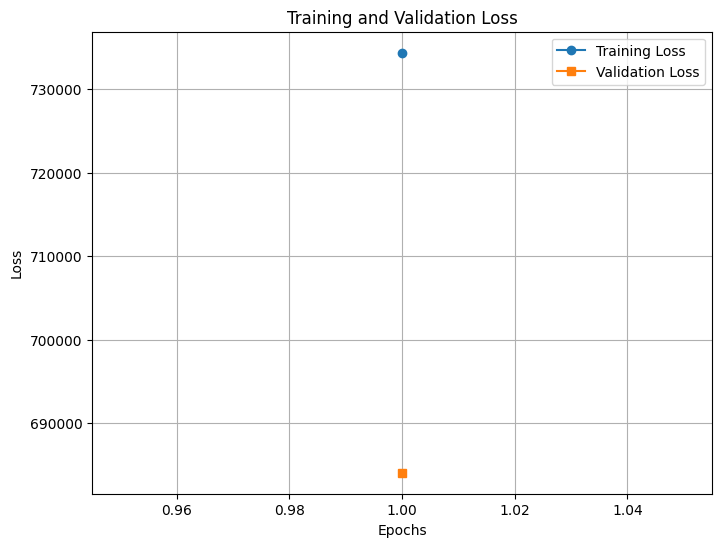

breastmnist
Train   AUC: 0.50000  Accuracy: 0.26923
Validation   AUC: 0.50000  Accuracy: 0.26923
Test   AUC: 0.50000  Accuracy: 0.26923



In [13]:
model = Net(in_channels=n_channels, num_classes=n_classes)
model.to(device)
optimiser = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)

test_AUC,test_ACC, val_auc, best_model, best_outputs, best_targets = full_training(model, num_epochs, criterion, optimiser, device, train_loader,train_evaluator, train_loader_at_eval,
                                                                          val_evaluator, val_loader, test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs)

## Question 1

### Task Overview

In this question, you will work on several foundational aspects of classification problems. Your tasks include:

- Defining and tuning hyperparameters.
- Implementing data augmentation techniques.
- Selecting and configuring appropriate optimizers.
- Designing and training a new classification model.

By the end of this task, you will demonstrate your ability to apply core machine learning concepts to build and refine models effectively.


## Question 1.1 (10 Marks)

### Task: Improve Model Performance

Currently, the model's performance is unsatisfactory, with a test AUC below 0.6. Your task is to adjust the following hyperparameters to improve the validation AUC so that `val_AUC > 0.8`:

- `num_epochs`
- `learning_rate`
- `weight_decay_rate`

Experiment with different values and observe how these changes impact the model's performance.

  7%|▋         | 1/15 [00:05<01:11,  5.12s/it]

New best validation AUC: 0.8070175438596491 at Epoch: 0


 13%|█▎        | 2/15 [00:08<00:54,  4.17s/it]

New best validation AUC: 0.8680033416875522 at Epoch: 1


 20%|██        | 3/15 [00:11<00:44,  3.74s/it]

...

New best validation AUC: 0.9507101086048455 at Epoch: 4


 47%|████▋     | 7/15 [00:24<00:21,  2.72s/it]

New best validation AUC: 0.9548872180451129 at Epoch: 6


100%|██████████| 15/15 [00:38<00:00,  2.56s/it]

New best validation AUC: 0.9624060150375939 at Epoch: 14


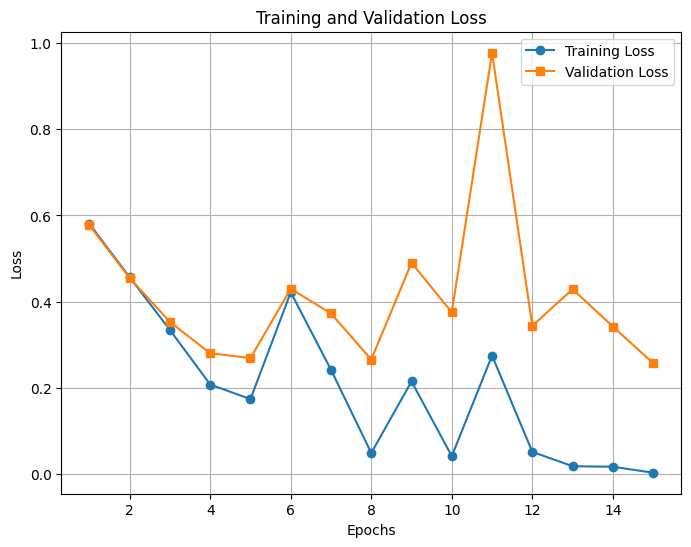

breastmnist
Train   AUC: 1.00000  Accuracy: 1.00000
Validation   AUC: 0.96241  Accuracy: 0.93590
Test   AUC: 0.89933  Accuracy: 0.87821



In [14]:
num_epochs = 1
# change learning_rate, weight_decay_rate, num_epochs to improve val_AUC

learning_rate = 1.0
weight_decay_rate = 0.0
num_epochs = 1

# YOUR CODE HERE
learning_rate = 0.001
weight_decay_rate = 1e-3
num_epochs = 15

model = Net(in_channels=n_channels, num_classes=n_classes)
model.to(device)
optimiser = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)

test_AUC,test_ACC, val_AUC, best_model, best_outputs, best_targets = full_training(model, num_epochs, criterion, optimiser, device, train_loader,train_evaluator, train_loader_at_eval,
                                                                          val_evaluator, val_loader, test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs)

In [15]:
print("Please do not erase this cell.")


print("Question 1.1: Improve model performance.")

Please do not erase this cell.
Question 1.1: Improve model performance.


In [16]:
print("Please do not erase this cell.")


print("Question 1.1: Improve model performance.")

Please do not erase this cell.
Question 1.1: Improve model performance.


## Question 1.2 (10 Marks)

### Task: Enhance Model Performance with Data Augmentation

Data augmentation is a simple yet effective technique to improve model performance by artificially increasing the training dataset through geometric and appearance transformations.  

In this question, you will apply the following data augmentations to the training images by modifying `train_transform`:  
1. **Random Rotations**: Apply random rotations up to ±10°.  
2. **Random Horizontal Flips**: Apply random horizontal flips with a probability of 50%.  

Incorporate these transformations and observe how they impact the training process and model performance.


  7%|▋         | 1/15 [00:02<00:38,  2.73s/it]

New best validation AUC: 0.7151211361737677 at Epoch: 0


 13%|█▎        | 2/15 [00:04<00:29,  2.23s/it]

New best validation AUC: 0.7869674185463659 at Epoch: 1


 20%|██        | 3/15 [00:06<00:24,  2.03s/it]

...

 27%|██▋       | 4/15 [00:08<00:21,  1.94s/it]

New best validation AUC: 0.8972431077694236 at Epoch: 3


 67%|██████▋   | 10/15 [00:20<00:09,  1.95s/it]

New best validation AUC: 0.923141186299081 at Epoch: 9


100%|██████████| 15/15 [00:30<00:00,  2.00s/it]


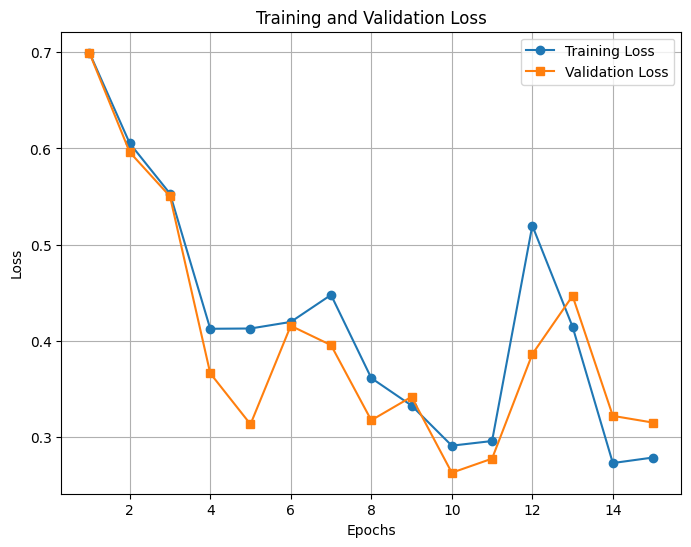

breastmnist
Train   AUC: 0.91978  Accuracy: 0.88095
Validation   AUC: 0.92314  Accuracy: 0.88462
Test   AUC: 0.86738  Accuracy: 0.80769



In [17]:
# Image pre-processing

# redefinition of train_transform
train_transform = transforms.Compose([
    # YOUR CODE HERE
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Datasets and DataLoaders
batch_size = 32
train_dataset = getattr(medmnist, INFO[data_flag]['python_class'])(split='train', transform=train_transform, download=True)
val_dataset = getattr(medmnist, INFO[data_flag]['python_class'])(split='val', transform=val_test_transform, download=True)
test_dataset = getattr(medmnist, INFO[data_flag]['python_class'])(split='test', transform=val_test_transform, download=True)


train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
train_loader_at_eval = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

train_evaluator = Evaluator(data_flag, 'train')
val_evaluator = Evaluator(data_flag, 'val')
test_evaluator = Evaluator(data_flag, 'test')

model = Net(in_channels=n_channels, num_classes=n_classes)
model.to(device)
optimiser = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)

test_AUC,test_ACC, val_AUC, best_model, best_outputs, best_targets = full_training(model, num_epochs, criterion, optimiser, device, train_loader,train_evaluator, train_loader_at_eval,
                                                                          val_evaluator, val_loader, test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs)



In [18]:
print("Please do not erase this cell.")


print("Question 1.2: Data augmentation.")

Please do not erase this cell.
Question 1.2: Data augmentation.


In [19]:
print("Please do not erase this cell.")


print("Question 1.2: Data augmentation.")

Please do not erase this cell.
Question 1.2: Data augmentation.


## Question 1.3 (10 Marks)

### Task: Compare Optimizers and Select the Best One

Optimizers play a critical role in the training process and significantly impact model performance. In this question, you will evaluate and compare the performance of two popular optimizers: **Adam** and **SGD**.  

Your tasks are as follows:  
1. Write a short code snippet to compare the validation AUC results of the two optimizers.  
2. Identify the optimizer that produces the best validation AUC.  
3. Use the selected optimizer to perform a final training run.  

Document your observations and the rationale behind your choice of optimizer.


  7%|▋         | 1/15 [00:01<00:25,  1.82s/it]

New best validation AUC: 0.606516290726817 at Epoch: 0


 13%|█▎        | 2/15 [00:03<00:23,  1.84s/it]

New best validation AUC: 0.8279030910609858 at Epoch: 1


 27%|██▋       | 4/15 [00:07<00:19,  1.81s/it]

...

 87%|████████▋ | 13/15 [00:25<00:04,  2.00s/it]

New best validation AUC: 0.894736842105263 at Epoch: 12


 93%|█████████▎| 14/15 [00:27<00:01,  1.95s/it]

New best validation AUC: 0.9039264828738514 at Epoch: 13


100%|██████████| 15/15 [00:29<00:00,  1.93s/it]


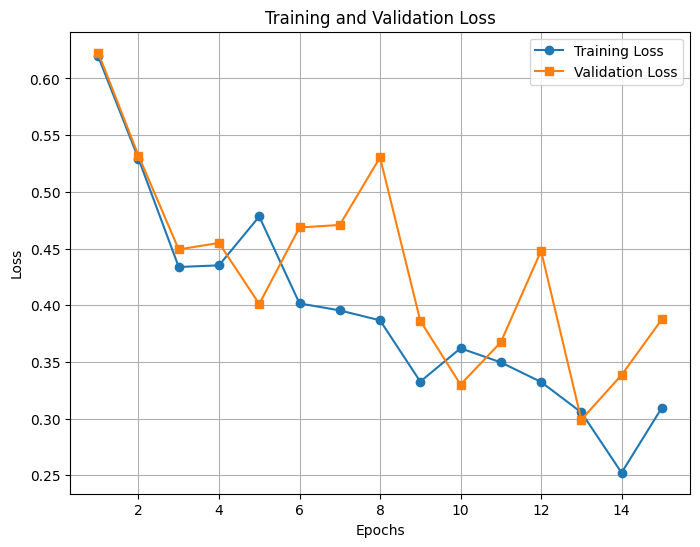

breastmnist
Train   AUC: 0.94534  Accuracy: 0.90293
Validation   AUC: 0.90393  Accuracy: 0.83333
Test   AUC: 0.85317  Accuracy: 0.85897



  7%|▋         | 1/15 [00:01<00:25,  1.84s/it]

New best validation AUC: 0.4987468671679198 at Epoch: 0


 13%|█▎        | 2/15 [00:03<00:25,  1.97s/it]

New best validation AUC: 0.620718462823726 at Epoch: 1


...

New best validation AUC: 0.6950710108604845 at Epoch: 12


 93%|█████████▎| 14/15 [00:29<00:02,  2.01s/it]

New best validation AUC: 0.6959064327485379 at Epoch: 13


100%|██████████| 15/15 [00:31<00:00,  2.13s/it]

New best validation AUC: 0.6984126984126984 at Epoch: 14


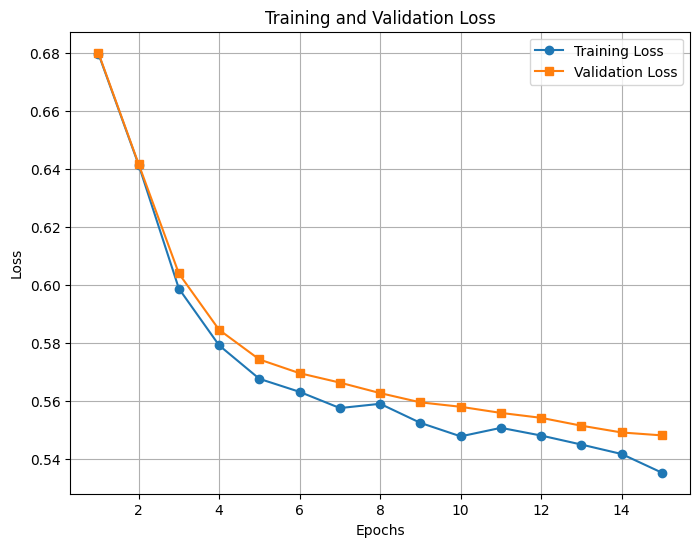

breastmnist
Train   AUC: 0.74697  Accuracy: 0.73077
Validation   AUC: 0.69841  Accuracy: 0.73077
Test   AUC: 0.74248  Accuracy: 0.73077



  7%|▋         | 1/15 [00:01<00:26,  1.87s/it]

New best validation AUC: 0.761904761904762 at Epoch: 0


 13%|█▎        | 2/15 [00:03<00:23,  1.83s/it]

New best validation AUC: 0.7894736842105263 at Epoch: 1


...

New best validation AUC: 0.9005847953216375 at Epoch: 8


 93%|█████████▎| 14/15 [00:27<00:01,  1.98s/it]

New best validation AUC: 0.9022556390977443 at Epoch: 13


100%|██████████| 15/15 [00:29<00:00,  1.95s/it]

New best validation AUC: 0.9114452798663325 at Epoch: 14


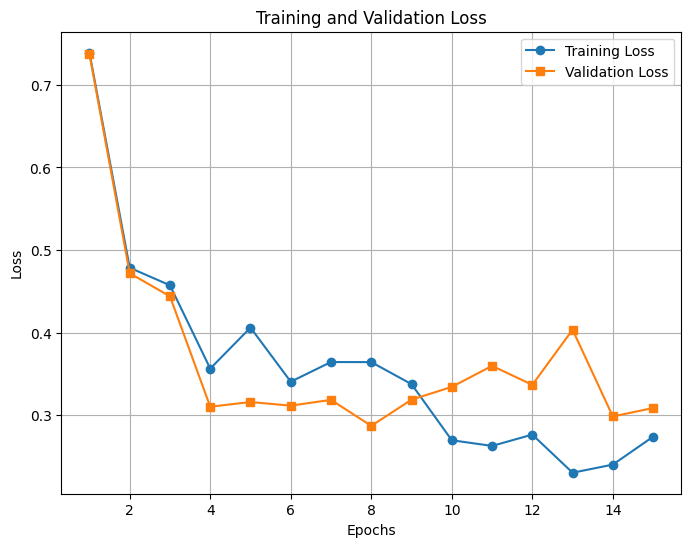

breastmnist
Train   AUC: 0.93380  Accuracy: 0.88462
Validation   AUC: 0.91145  Accuracy: 0.84615
Test   AUC: 0.87302  Accuracy: 0.83974



In [20]:
model = Net(in_channels=n_channels, num_classes=n_classes)
model.to(device)

# Select Adam optimiser
# YOUR CODE HERE
optimiser = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)

_,_,val_AUC_Adam, _, _,_ = full_training(model, num_epochs, criterion, optimiser, device, train_loader,train_evaluator, train_loader_at_eval,
                                                                          val_evaluator, val_loader, test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs)

model = Net(in_channels=n_channels, num_classes=n_classes)
model.to(device)

# Select SGD optimiser
# YOUR CODE HERE
optimiser = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)


_,_,val_AUC_SGD, _, _,_ = full_training(model, num_epochs, criterion, optimiser, device, train_loader,train_evaluator, train_loader_at_eval,
                                                                          val_evaluator, val_loader, test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs)

model = Net(in_channels=n_channels, num_classes=n_classes)
model.to(device)

# Select the best of the two optimisers
# YOUR CODE HERE
optimiser = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)


test_AUC,test_ACC, val_AUC, best_model, best_outputs, best_targets = full_training(model, num_epochs, criterion, optimiser, device, train_loader,train_evaluator, train_loader_at_eval,
                                                                          val_evaluator, val_loader, test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs)


In [21]:
print("Please do not erase this cell.")


print("Question 1.3: Select optimiser.")

Please do not erase this cell.
Question 1.3: Select optimiser.


## Question 1.4 (10 Marks)

### Task: Build a New CNN Model from Scratch

In this question, you will design and train a new convolutional neural network (CNN) model. Follow the steps below to define a new class called `Net2` and train a model named `model2`.  

### Architecture of `Net2`:
1. **Layer 1**:  
   - Convolutional layer with 32 filters of size \(5 \times 5\).  
   - Followed by a ReLU activation function.  
   - Max pooling with kernel size = 3 and stride = 3.  
   
2. **Fully Connected (fc) Layer**:  
   - Linear layer with 300 nodes, followed by a ReLU activation function.  
   - Another linear layer with `num_classes` nodes for classification.  

### Instructions:
- Implement the `Net2` class with the specified architecture.  
- Train the `model2` using the new architecture.  
- Ensure that the training code and hyperparameter configuration are included.  

Document your observations and report the model's performance metrics (e.g., accuracy, AUC) on the validation and test sets.


  7%|▋         | 1/15 [00:02<00:40,  2.91s/it]

New best validation AUC: 0.7827903091060986 at Epoch: 0


 13%|█▎        | 2/15 [00:04<00:25,  1.93s/it]

New best validation AUC: 0.8036758563074353 at Epoch: 1


 20%|██        | 3/15 [00:05<00:17,  1.49s/it]

...

 60%|██████    | 9/15 [00:11<00:06,  1.08s/it]

New best validation AUC: 0.8395989974937343 at Epoch: 8


 67%|██████▋   | 10/15 [00:12<00:05,  1.04s/it]

New best validation AUC: 0.8529657477025898 at Epoch: 9


100%|██████████| 15/15 [00:17<00:00,  1.20s/it]


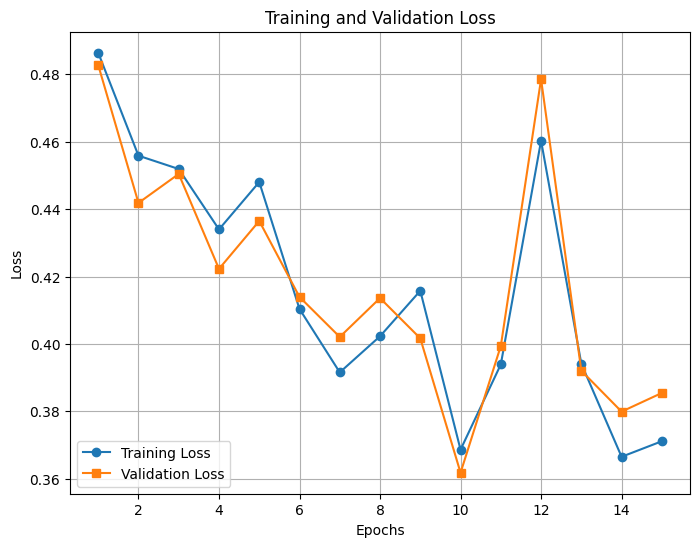

breastmnist
Train   AUC: 0.87210  Accuracy: 0.83883
Validation   AUC: 0.85297  Accuracy: 0.84615
Test   AUC: 0.86842  Accuracy: 0.86538



In [28]:
# define the new CNN model
class Net2(nn.Module):
    # YOUR CODE HERE
    def __init__(self, in_channels, num_classes):
        super(Net2, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=5, padding=0)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=3, stride=3)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 8 * 8, 300)
        self.fc2 = nn.Linear(300, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x



model2 = Net2(in_channels=n_channels, num_classes=n_classes)
model2.to(device)
optimiser = optim.Adam(model2.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)

_,_, _, _,_,_ = full_training(model2, num_epochs, criterion, optimiser, device, train_loader,train_evaluator, train_loader_at_eval,
                            val_evaluator, val_loader, test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs)


In [29]:
print("Please do not erase this cell.")


print("Question 1.4: New CNN model.")

Please do not erase this cell.
Question 1.4: New CNN model.


## Question 2 (10 Marks)

### Task: Compute and Analyze Classification Metrics

Evaluating the performance of CNN models requires analyzing various metrics that provide insights into their effectiveness. In this question, you will compute some of these key metrics.

### Instructions:
Write a Python function named `compute_classification_metrics(all_outputs, all_targets)` that calculates and returns the following metrics for classifications of the positive class (with probability > 0.5):  
1. **Area Under the Precision-Recall Curve (AUPR)**  
2. **Precision**  
3. **Recall**  
4. **F1 Score**  

### Requirements:
- Use the following functions from `sklearn.metrics`:  
  - `precision_score`  
  - `recall_score`  
  - `f1_score`  
  - `precision_recall_curve`  
  - `auc`  

Ensure your implementation is correct and efficient. Comment your code to explain the key steps.


In [84]:
def compute_classification_metrics(all_outputs, all_targets):

    probability_threshold = 0.5

    """
    Here we use sigmoid to turn all the output output values to a probability
    actually not technically probability but a number between 0-1, so we
    can then turn it into a classification and comparing it using the
    probability threshold to filter to turn the values to 0 and 1, this
    will allow us compare with the target results.
    """
    pred = (torch.sigmoid(all_outputs) >= probability_threshold).float()

    #sliced the data to pick the second column
    pred = pred[:,1]

    #trasnformed the target values into a 1d tensor in order to compute
    targets = all_targets.view(-1)


    #computing the precision and recall curve to calculate the are under
    precision, recall, thresh = precision_recall_curve(targets, pred)
    auc_pr = auc(recall, precision)


    precision_score_val = precision_score(targets, pred)
    recall_score_val    = recall_score(targets, pred)
    f1_score_val = f1_score(targets, pred)

    print(f'AUPR: {auc_pr:.5f}')
    print(f'Precision: {precision_score_val:.5f}')
    print(f'Recall: {recall_score_val:.5f}')
    print(f'F1 Score: {f1_score_val:.5f}')

    return recall, precision, auc_pr, precision_score_val, recall_score_val, f1_score_val


# Recall, precision, auc_pr stored in variables for use in plotting graphs
print('Metrics')
recall, precision, auc_pr, precision_score_val, recall_score_val, f1_score_val = compute_classification_metrics(best_outputs, best_targets)

Metrics
AUPR: 0.90881
Precision: 0.82707
Recall: 0.96491
F1 Score: 0.89069


In [ ]:
print("Please do not erase this cell.")


print("Question 2: Classification metrics")

In [ ]:
print("Please do not erase this cell.")


print("Question 2: Classification metrics")

In [ ]:
print("Please do not erase this cell.")


print("Question 2: Classification metrics")

In [ ]:
print("Please do not erase this cell.")


print("Question 2: Classification metrics")

## Question 3 (10 Marks)

### Task: Define the Class Probability for Plotting the ROC Curve

The Receiver Operating Characteristic (ROC) curve is a crucial tool for evaluating the performance of classifiers. Since our classification problem involves two classes, it is essential to specify which class probability should be used to plot the ROC curve. In particular, we are interested in the classification of normal/benign cases.

### Instructions:
In this question, we provide a partially implemented function to plot the ROC curve. However, the definition of which class probability to select is missing. Your task is to:
1. Select the appropriate class probability for the normal/benign case from the `all_outputs` array.
2. Use this probability to correctly plot the ROC curve.

### Reminder:
Ensure that the selected probability corresponds to the positive class, as the ROC curve evaluates the trade-off between the true positive rate (sensitivity) and the false positive rate. Your implementation should be correct and result in a valid ROC curve.


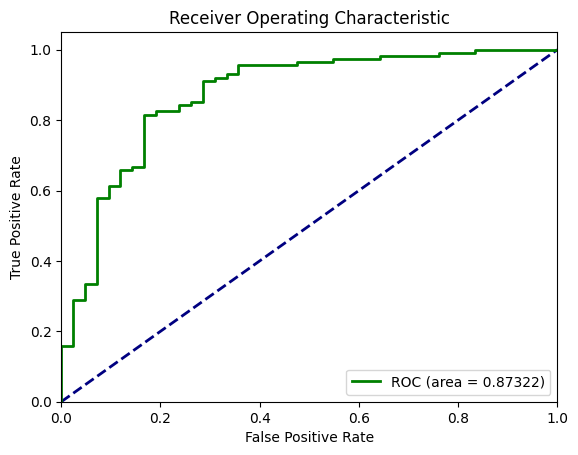

In [75]:
def plot_roc_curve(all_outputs, all_targets, label, color):

    # initialise probabilities
    probabilities = 1.0*torch.ones(best_outputs.shape[0])

    # set the probabilities here:
    # YOUR CODE HERE
    probabilities = torch.sigmoid(all_outputs)[:, 1]




    probabilities = probabilities.detach().cpu().numpy()
    if not(np.all((probabilities >= 0) & (probabilities <= 1))):
        print("probabilities are out of range: {probabilities}. Expected 0 <= probabilities <= 1.")

    all_targets = all_targets.squeeze().cpu().numpy()  # Ensure correct shape for sklearn functions

    fpr, tpr, thresholds = sk_roc_curve(all_targets, probabilities)
    roc_auc = auc(fpr, tpr)  # Calculate the area under the curve

    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (area = {roc_auc:.5f})')

    return probabilities

# Set up the plot
plt.figure()
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')

# Plot each model's ROC curve
probabilities = plot_roc_curve(best_outputs, best_targets, label='ROC', color='green')

plt.legend(loc="lower right")
plt.show()

In [ ]:
print("Please do not erase this cell.")



print("Question 3: ROC curve")


In [ ]:
print("Please do not erase this cell.")



print("Question 3: ROC curve")


In [ ]:
print("Please do not erase this cell.")



print("Question 3: ROC curve")


## Question 4 (10 Marks)

### Task: Compute the Confusion Matrix for Classification

In addition to the ROC curve, the confusion matrix is a vital tool for visualizing the performance of a classifier. It provides insights into the true positives, false positives, true negatives, and false negatives, offering a detailed breakdown of classification accuracy.

### Instructions:
Write a Python function named `compute_confusion_matrix(all_outputs, all_targets)` that:  
1. Receives the following inputs:  
   - `all_outputs`: An array containing the classification confidences for each class.  
   - `all_targets`: An array containing the ground-truth labels.  

2. Computes the confusion matrix for the classification task.

### Requirements:
- Ensure that the function correctly maps classification confidences to predicted labels by selecting the class with the highest confidence for each input.  
- Use appropriate functions from libraries like `sklearn.metrics` or implement the logic manually.  
- Comment your code to explain key steps and ensure clarity.

### Deliverables:
- A working definition of the `compute_confusion_matrix` function.  
- Visualize the computed confusion matrix as a heatmap using a library such as Matplotlib or Seaborn (optional but encouraged).  


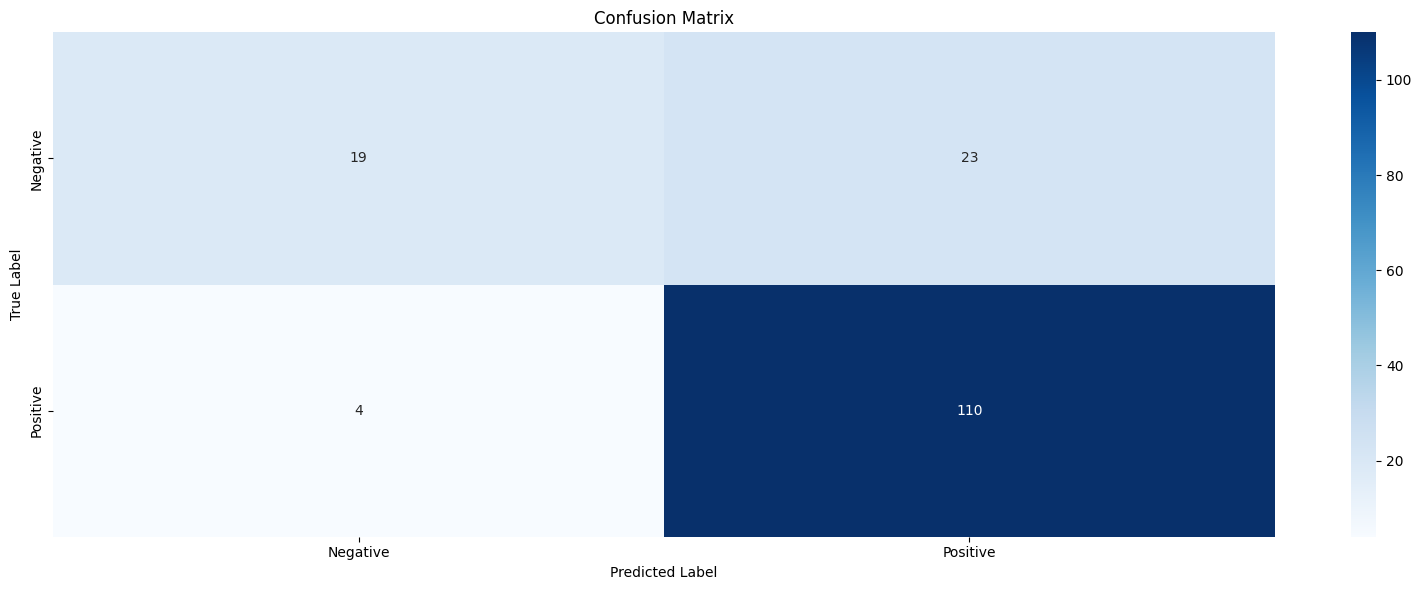

In [86]:
def compute_confusion_matrix(all_outputs, all_targets):
    # initialise confusion matrix
    cm = 100*np.ones((2,2))
    cm[0,0]=90
    cm[1,1]=110

    # YOUR CODE HERE
    pred = (torch.sigmoid(all_outputs) >= 0.5).float()

    #sliced the data to pick the second column
    pred = pred[:,1]

    #trasnformed the target values into a 1d tensor in order to compute
    targets = all_targets.view(-1)

    cm = confusion_matrix(targets, pred)


    return cm

def plot_confusion_matrix(cm, class_names, title, ax, colour):
    sns.heatmap(cm, annot=True, fmt='d', cmap=colour, xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))

cm = compute_confusion_matrix(best_outputs, best_targets)
plot_confusion_matrix(cm, ['Negative', 'Positive'], 'Confusion Matrix', axes,colour='Blues')

plt.tight_layout()
plt.show()


In [ ]:
print("Please do not erase this cell.")


print("Question 4: Confusion matrix computation.")


In [ ]:
print("Please do not erase this cell.")


print("Question 4: Confusion matrix computation.")


## Question 5 - Cross Validation (10 Marks)

### Task: Implement Cross Validation for Robust Model Assessment

To ensure a more reliable and robust evaluation of a classifier, cross-validation is a standard approach. It provides insights into the model's performance by evaluating it across multiple splits of the dataset, reducing the risk of overfitting to a single data split.

### Instructions:
In this question, you will:  
1. **Combine Datasets**: Concatenate the training, validation, and testing datasets into a single unified dataset.  
2. **Define K-Fold Object**: Use a K-fold cross-validation strategy to split the dataset into `K` subsets (folds).  
3. **Evaluate the Model**: Implement a method to train and evaluate the model using cross-validation. Ensure the model is trained on `K-1` folds and validated on the remaining fold in each iteration.

### Requirements:
- Use a suitable library like `sklearn.model_selection.KFold` for creating the K-fold object.
- Report the average and per-fold metrics (e.g., accuracy, AUC) to summarize the model's performance.
- Comment your code to explain the key steps, such as splitting the data, training the model, and aggregating results.
- Optionally, visualize the fold-specific metrics for better interpretation.

### Deliverables:
- A complete implementation of cross-validation for the provided model.
- A summary of cross-validation results, including:
  - Metrics for each fold (e.g., AUC, accuracy).
  - Overall average metrics across all folds.


In [87]:
# Concatenate the data sets and split it into 5 splits.
combined_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset, test_dataset])
kf = KFold(n_splits=5, shuffle=True)

def evaluate_cross_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, torch.squeeze(targets, 1).long())
            total_loss += loss.item()

            probs = torch.nn.functional.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()

            all_probs.extend(probs)
            all_targets.extend(targets.cpu().numpy().squeeze())

    test_loss = total_loss / len(data_loader)

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    auc = roc_auc_score(all_targets, all_probs)
    acc = accuracy_score(all_targets, all_probs > 0.5)

    return test_loss, auc, acc


## Question 5.1 - Fix Cross-Validation Implementation (10 Marks)

### Task: Correct the Implementation of Cross-Validation

The function `cross_validate_model_with_serious_mistake(combined_dataset, kf, learning_rate, weight_decay_rate, num_epochs)` contains a flawed implementation of the cross-validation process. Your task is to identify and correct the mistakes in this function, resulting in a properly implemented function named `cross_validate_model(combined_dataset, kf, learning_rate, weight_decay_rate, num_epochs)`.

### Instructions:
1. **Understand the Provided Code**: Analyze the incorrect implementation of the function `cross_validate_model_with_serious_mistake` to identify logical and procedural errors in the cross-validation process.
2. **Fix the Function**: Modify the function to ensure that the cross-validation is performed correctly, including:
   - Properly splitting the combined dataset into training and validation subsets for each fold using the provided K-fold object (`kf`).
   - Training the model on `K-1` folds and validating it on the remaining fold.
   - Averaging the performance metrics (e.g., AUC, accuracy) across all folds.
3. **Validate Your Fix**: Test the corrected function to ensure that it produces accurate and meaningful cross-validation results.

### Requirements:
- Use the provided `combined_dataset` and `kf` (K-fold object) for the cross-validation process.
- Ensure proper handling of data splits to avoid data leakage.
- Calculate and return the average and per-fold metrics (e.g., AUC, accuracy).
- Comment your code to highlight the fixes made to the original function.

### Deliverables:
- A corrected implementation of the cross-validation function as `cross_validate_model(combined_dataset, kf, learning_rate, weight_decay_rate, num_epochs)`.
- A summary of the cross-validation results, including:
  - Per-fold metrics (e.g., AUC, accuracy).
  - Overall average metrics across all folds.

### Note:
Ensure that the fixed function adheres to best practices in cross-validation and avoids common pitfalls such as reusing the same data for both training and validation in a single fold.


In [88]:
def cross_validate_model_with_serious_mistake(combined_dataset,kf,learning_rate,weight_decay_rate,num_epochs):
    fold_results = []

    model = Net(in_channels=n_channels, num_classes=n_classes)

    for fold, (train_val_index, test_index) in enumerate(kf.split(combined_dataset)):
        # Split train+validation and test datasets
        train_val_subset = torch.utils.data.Subset(combined_dataset, train_val_index)
        test_subset = torch.utils.data.Subset(combined_dataset, test_index)

        # Split train+validation into their own sets
        sub_kf = KFold(n_splits=4, shuffle=True)
        train_index, val_index = next(iter(sub_kf.split(train_val_subset)))
        train_subset = torch.utils.data.Subset(train_val_subset, train_index)
        val_subset = torch.utils.data.Subset(train_val_subset, val_index)

        model.to(device)
        optimiser = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)
        criterion = nn.CrossEntropyLoss()


        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

        # Training
        for epoch in range(num_epochs):
            train_model(model, train_loader, criterion, optimiser, device)

        # Evaluation
        val_metrics = evaluate_cross_model(model, val_loader, criterion, device)
        test_metrics = evaluate_cross_model(model, test_loader, criterion, device)
        test_auc = test_metrics[1]
        test_acc = test_metrics[2]

        fold_results.append((test_metrics[0], test_auc, test_acc))
        print(f"Fold {fold+1}: Test loss={test_metrics[0]:.4f}, Test AUC={test_auc:.5f}, Test accuracy={test_acc:.5f}")

    return fold_results

# Compute average AUC and accuracy across all 5 folds
results = cross_validate_model_with_serious_mistake(combined_dataset,kf,learning_rate,weight_decay_rate,num_epochs)
average_auc = np.mean([r[1] for r in results])
average_acc = np.mean([r[2] for r in results])

print()
print(f'Average test AUC: {average_auc:.5f}')
print(f'Average test accuracy: {average_acc:.5f}')

KeyboardInterrupt: 

In [94]:
def cross_validate_model(combined_dataset,kf,learning_rate,weight_decay_rate,num_epochs):
    fold_results = []
    # initialise fold_results
    for i in range(5): fold_results.append((1.0,1.0,1.0))

    for fold, (train_val_index, test_index) in enumerate(kf.split(combined_dataset)):
        # Split train+validation and test datasets
        train_val_subset = torch.utils.data.Subset(combined_dataset, train_val_index)
        test_subset = torch.utils.data.Subset(combined_dataset, test_index)

        # 1 NO need to split again the change I made was removed the extra split of data
        train_subset = train_val_subset
        val_subset = train_val_subset

        """ I moved this line of code inside the for loop becasue preivously the model memorized
            the previous weights instead it should be restarting fresh on each k fold"""
        model = Net(in_channels=n_channels, num_classes=n_classes).to(device)
        optimiser = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay_rate
        )
        criterion = nn.CrossEntropyLoss()


        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(test_subset,  batch_size=batch_size, shuffle=False)


        for epoch in range(num_epochs):
            train_model(model, train_loader, criterion, optimiser, device)


        val_metrics  = evaluate_cross_model(model, val_loader, criterion, device)
        test_metrics = evaluate_cross_model(model, test_loader, criterion, device)
        test_auc = test_metrics[1]
        test_acc = test_metrics[2]

        fold_results.append((test_metrics[0], test_auc, test_acc))
        print(f"Fold {fold+1}: Test loss={test_metrics[0]:.4f}, Test AUC={test_auc:.5f}, Test accuracy={test_acc:.5f}")




    return fold_results

# Compute average AUC and accuracy across all 5 folds
results = cross_validate_model(combined_dataset,kf,learning_rate,weight_decay_rate,num_epochs)
average_auc = np.mean([r[1] for r in results])
average_acc = np.mean([r[2] for r in results])

print()
print(f'Average test AUC: {average_auc:.5f}')
print(f'Average test accuracy: {average_acc:.5f}')

Fold 1: Test loss=0.4913, Test AUC=0.86790, Test accuracy=0.80769
Fold 2: Test loss=0.4106, Test AUC=0.86084, Test accuracy=0.86538
Fold 3: Test loss=0.6887, Test AUC=0.87731, Test accuracy=0.76923
Fold 4: Test loss=0.5431, Test AUC=0.86351, Test accuracy=0.82692
Fold 5: Test loss=0.4207, Test AUC=0.88247, Test accuracy=0.87821

Average test AUC: 0.93520
Average test accuracy: 0.91474


In [ ]:
print("Please do not erase this cell.")



print("Question 5: Cross validation.")

## Question 6 - Fine-Tuning a Pre-Trained ResNet18 Model (20 marks)

### Task: Fine-Tune a Pre-Trained ResNet18 Model

In this question, you will fine-tune a pre-trained ResNet18 model on your dataset. We will guide you through the key modifications required to adapt the model for your task, and you will need to make the necessary changes to ensure the model is correctly fine-tuned.

### Instructions:
1. **Understand the Pre-Trained Model**: Familiarize yourself with the ResNet18 architecture and its pre-trained weights.
2. **Model Adaptation**: Adjust the model for your specific dataset by:
   - Modifying the final layer to match the number of classes in your classification task.
   - Freezing or unfreezing certain layers as needed for fine-tuning.
3. **Optimization**: Choose appropriate hyperparameters (e.g., learning rate) for fine-tuning the model and ensure that the training procedure is set up correctly.
4. **Validation**: Verify that the model fine-tuning process improves the performance on the validation set.

### Deliverables:
- A fine-tuned ResNet18 model.
- Code changes to adapt the pre-trained model and ensure it works with your dataset.
- A brief explanation of the changes you made and the rationale behind them.

### Note:
- Fine-tuning typically involves freezing the early layers (which capture general features) and training only the later layers (which capture task-specific features). Make sure to experiment with different approaches to achieve the best performance.


## Question 6.1 - Preprocessing for Fine-Tuning ResNet18 (10 Marks)

### Task: Modify Image Preprocessing for ResNet18 Fine-Tuning

The pre-trained ResNet18 model from ImageNet is designed to work with RGB images of size 224x224x3, and the images should be normalized according to the statistics learned from the ImageNet dataset.

In this question, you need to modify the `train_transform` and `val_test_transform` to ensure that the images are preprocessed correctly for fine-tuning with ResNet18. Specifically, you need to make the following changes:

1. **Resize the Images**: The input size for ResNet18 is 224x224 pixels. Use `transforms.Resize(224)` to resize the images to this size.
   
2. **Convert to RGB Channels**: The ResNet18 model expects 3 channels (RGB). If your images are grayscale (1 channel), you need to convert them to 3 channels. Use `transforms.Lambda(lambda x: x.repeat(3, 1, 1))` for this transformation.

3. **Normalize the Images**: The images should be normalized using the mean and standard deviation values derived from the ImageNet dataset. Use `transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])` for this normalization step.

### Deliverables:
- Updated `train_transform` and `val_test_transform` that resize, convert to RGB, and normalize images as described.
- Brief explanation of the transformations applied.

### Hint:
- Carefully check the order of transformations. The resize operation should be applied before the conversion to RGB channels and normalization.


In [98]:
# Image pre-processing
train_transform = transforms.Compose([
    # YOUR CODE HERE
    transforms.Resize(224),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    # YOUR CODE HERE
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    # YOUR CODE HERE
    transforms.Resize(224),
    transforms.ToTensor(),
    # YOUR CODE HERE
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets and DataLoaders
train_dataset = getattr(medmnist, INFO[data_flag]['python_class'])(split='train', transform=train_transform, download=True)
val_dataset = getattr(medmnist, INFO[data_flag]['python_class'])(split='val', transform=val_test_transform, download=True)
test_dataset = getattr(medmnist, INFO[data_flag]['python_class'])(split='test', transform=val_test_transform, download=True)

batch_size = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
train_loader_at_eval = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

train_evaluator = Evaluator(data_flag, 'train')
val_evaluator = Evaluator(data_flag, 'val')
test_evaluator = Evaluator(data_flag, 'test')

In [ ]:
print("Please do not erase this cell.")


print("Question 6.1: Change the train_transform and val_test_transform.")


In [ ]:
print("Please do not erase this cell.")


print("Question 6.1: Change the train_transform and val_test_transform.")


## Question 6.2 - Modify the ResNet18 Architecture (10 Marks)

### Task: Load and Modify the Pre-Trained ResNet18 Model

In this question, you will load the pre-trained ResNet18 model from torchvision and modify it for your classification task.

1. **Load the Pre-Trained ResNet18 Model**:
   - Use the `torchvision.models.resnet18` function to load the ResNet18 model.
   - Ensure that the model is initialized with weights from the ImageNet dataset (use `weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1` as per the torchvision documentation).

2. **Modify the Final Fully Connected Layer**:
   - After loading the model, modify the final fully connected layer (`model.fc`) to have `n_classes` output nodes, where `n_classes` is the number of classes in your classification task.

### Deliverables:
- Code that loads the ResNet18 model with ImageNet weights and modifies the final fully connected layer to match the number of classes in your dataset.

### Hint:
- The final fully connected layer is typically accessed via `model.fc`. You will need to update its output dimension to match `n_classes`.


In [ ]:
from torchvision import models

# Model setup
# Initialize from our Net model
model_RN18 = Net(in_channels=n_channels, num_classes=n_classes)

# YOUR CODE HERE
model_RN18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_RN18.fc = nn.Linear(model_RN18.fc.in_features, n_classes)

model_RN18.to(device)

optimiser = optim.Adam(model_RN18.parameters(), lr=learning_rate, weight_decay=weight_decay_rate)
num_epochs = 5
test_AUC,test_ACC, val_auc, best_model, best_outputs, best_targets = full_training(model_RN18, num_epochs, criterion, optimiser, device, train_loader,train_evaluator, train_loader_at_eval,
                                                                          val_evaluator, val_loader, test_evaluator, test_loader, log_dict, train_logs, val_logs, test_logs)



  0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
print("Please do not erase this cell.")


print("Question 6.2: ResNet18.")



In [ ]:
print("Please do not erase this cell.")


print("Question 6.2: ResNet18.")

